# Metric3D v2: 

Modelo de Cimentación Geométrica Versátil Metric3D v2 es un modelo diseñado para la estimación de profundidad métrica (distancia absoluta) y normales de superficie a partir de una sola imagen (monocular). A diferencia de modelos anteriores que se enfocan en profundidad invariante a la escala, Metric3D v2 permite la reconstrucción 3D con dimensiones reales del mundo físico, lo que facilita tareas como la metrología y el mapeo denso en SLAM.

## Introduccion
El reto principal en la visión monocular es la ambigüedad métrica. Sin conocer los parámetros de la cámara (específicamente la distancia focal), el modelo no puede distinguir si un objeto es pequeño y está cerca, o si es grande y está lejos.

Metric3D v2 resuelve esto mediante:


* Generalización Zero-shot: Capacidad de funcionar en imágenes "en la naturaleza" con cámaras nunca antes vistas durante el entrenamiento.

* Aprendizaje a Gran Escala: Entrenado con más de 16 millones de imágenes de miles de modelos de cámaras diferentes.

* Multitarea Sinergizada: Estima profundidad y normales simultáneamente, aprovechando que ambas propiedades están geométricamente relacionadas y son complementarias.

2. Arquitectura

La arquitectura de Metric3D v2 se compone de tres pilares fundamentales que permiten su precisión y versatilidad:

* **A. Módulo de Transformación de Cámara Canónica (CSTM)**

Para resolver la ambigüedad métrica causada por diferentes distancias focales, los autores proponen transformar todos los datos de entrenamiento a un espacio de cámara canónica único.

Existen dos métodos para esta transformación:


* **Transformación de etiquetas (CSTM_label):** Se reescala la profundidad real (ground-truth) según la relación entre la distancia focal canónica y la real de la cámara.

* **Transformación de imágenes (CSTM_image):** Se redimensiona la imagen de entrada para simular los efectos visuales de una cámara canónica.

Este módulo permite que la red aprenda una distribución métrica unificada sin tener que codificar explícitamente los modelos de cámara dentro de la red neuronal, lo que facilita su integración en arquitecturas existentes como ViT.

* **B. Optimización Conjunta Profundidad-Normal**

Dado que las anotaciones de normales de superficie son escasas (especialmente en exteriores), el modelo utiliza un módulo de optimización recurrente para destilar conocimiento desde los datos de profundidad hacia los de normales.

* **Bloques Recurrentes (ConvGRU):** Inspirado en RAFT, el modelo optimiza iterativamente mapas de profundidad y normales de baja resolución.

* **Fuentes de Aprendizaje:** Las normales aprenden de:

* Etiquetas reales de normales (cuando existen).

* Consistencia geométrica explícita entre profundidad y normal.

* Transferencia de características implícita a través de la fusión de features en el optimizador.

* **C. Pérdida de Normalización de Propuestas Aleatorias (RPN Loss)**
Para mejorar la precisión en los detalles finos, se introduce esta función de pérdida que selecciona parches aleatorios de la imagen. En lugar de normalizar toda la imagen (lo que puede ``aplastar`` diferencias sutiles), esta pérdida enfatiza la geometría local y la distribución de profundidad dentro de áreas específicas de la escena.

In [7]:
import onnxruntime as ort
import numpy as np
import cv2
from typing import Tuple, Dict, List
from matplotlib import pyplot as plt
from functions.graphic_comparation import graphic_comparation

import sys
import os
sys.path.append(os.path.abspath("."))

In [8]:
def prepare_input(
    rgb_image: np.ndarray, input_size: Tuple[int, int]
) -> Tuple[Dict[str, np.ndarray], List[int]]:

    h, w = rgb_image.shape[:2]
    scale = min(input_size[0] / h, input_size[1] / w)
    rgb = cv2.resize(
        rgb_image, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_LINEAR
    )

    padding = [123.675, 116.28, 103.53]
    h, w = rgb.shape[:2]
    pad_h = input_size[0] - h
    pad_w = input_size[1] - w
    pad_h_half = pad_h // 2
    pad_w_half = pad_w // 2
    rgb: np.ndarray = cv2.copyMakeBorder(
        rgb,
        pad_h_half,
        pad_h - pad_h_half,
        pad_w_half,
        pad_w - pad_w_half,
        cv2.BORDER_CONSTANT,
        value=padding,
    )
    pad_info = [pad_h_half, pad_h - pad_h_half, pad_w_half, pad_w - pad_w_half]

    onnx_input = {
        "image": np.ascontiguousarray(
            np.transpose(rgb, (2, 0, 1))[None], dtype=np.float32
        ),  # 1, 3, H, W
    }
    return onnx_input, pad_info

In [9]:
def get_infer_image(onnx_model, input_image, output_image):
    B = 1
    if "vit" in onnx_model:
        input_size = (616, 1064)  # [H, W]
        dummy_image = np.zeros([B, 3, input_size[0], input_size[1]], dtype=np.float32)
    else:
        input_size = (544, 1216)  # [H, W]
        dummy_image = np.zeros([B, 3, input_size[0], input_size[1]], dtype=np.float32)

    providers = [
        (
            "CUDAExecutionProvider",
            {"cudnn_conv_use_max_workspace": "0", "device_id": str(0)},
        )
    ]

    # providers = [("TensorrtExecutionProvider", {'trt_engine_cache_enable': True, 'trt_fp16_enable': True, 'device_id': 0, 'trt_dla_enable': False})]
    ort_session = ort.InferenceSession(onnx_model, providers=providers)
    outputs = ort_session.run(None, {"pixel_values": dummy_image})

    print(
        f"The actual output of onnxruntime session for the dummy set: outputs[0].shape={outputs[0].shape}"
    )

    ## Real Test
    rgb_image = cv2.imread(input_image)[:, :, ::-1]  # BGR to RGB
    original_shape = rgb_image.shape[:2]
    onnx_input, pad_info = prepare_input(rgb_image, input_size)
    outputs = ort_session.run(None, {"pixel_values": onnx_input["image"]})
    depth = outputs[0].squeeze()  # [H, W]

    # Reshape the depth to the original size
    depth = depth[
        pad_info[0] : input_size[0] - pad_info[1],
        pad_info[2] : input_size[1] - pad_info[3],
    ]
    depth = cv2.resize(
        depth, (original_shape[1], original_shape[0]), interpolation=cv2.INTER_LINEAR
    )

    depth_vis = cv2.normalize(depth, None, 0, 255, cv2.NORM_MINMAX)
    depth_vis = depth_vis.astype(np.uint8)

    # Apply colormap to make it colorful like in the plot
    depth_colored = cv2.applyColorMap(depth_vis, cv2.COLORMAP_JET)
    cv2.imwrite(output_image, depth_colored)
    graphic_comparation(rgb_image, depth)

## 3.- Resultados con imagenes
Gracias a esta arquitectura, el modelo ha logrado resultados destacados:
* Metrología: Permite medir objetos reales (como drones o muebles) con precisión milimétrica desde una sola foto.
* SLAM Monocular: Al proporcionar una escala métrica estable, elimina la deriva de escala (scale drift) en algoritmos de navegación para robots y drones.
* Benchmarks: Clasifica actualmente en el primer lugar en múltiples pruebas de rendimiento (NYUv2, KITTI, etc.), superando a modelos recientes como Marigold y DepthAnything.

The actual output of onnxruntime session for the dummy set: outputs[0].shape=(1, 532, 1204)


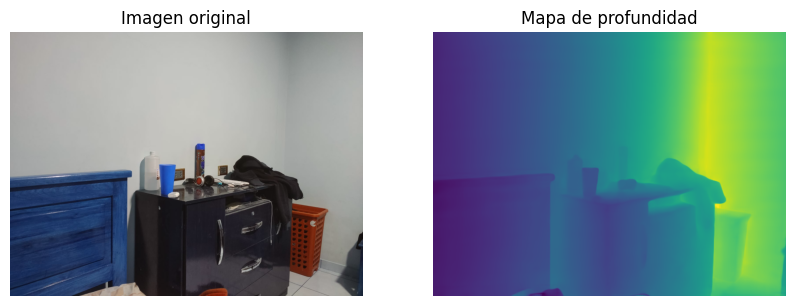

In [10]:
onnx_model="./checkpoints/v2-S-ONNX/model.onnx"
input_image="./assets/examples/example01.jpeg"
output_image="./assets/results/example01.jpeg"

get_infer_image(onnx_model, input_image, output_image)

The actual output of onnxruntime session for the dummy set: outputs[0].shape=(1, 532, 1204)


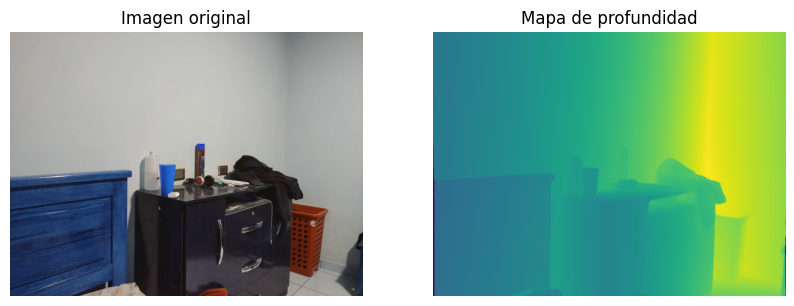

In [13]:
onnx_model="./checkpoints/v2-L-ONNX/model.onnx"
input_image="./assets/examples/example01.jpeg"
output_image="./assets/results/example01.jpeg"

get_infer_image(onnx_model, input_image, output_image)

In [12]:
# onnx_model="./checkpoints/v3-G-ONNX/model_fp16.onnx"
# input_image="./assets/examples/demo01.jpg"
# output_image="./assets/results/demo01_l.jpg"

# get_infer_image(onnx_model, input_image, output_image)

## Referencias

- Metric3d V2. Disponible en: https://github.com/YvanYin/Metric3D

## Credits

This project uses components from the Metric3d V2 repository.

Original repository:
https://github.com/YvanYin/Metric3D

Licensed under the BSD 2-Clause License